In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, desc
import sys

In [2]:
spark = SparkSession.builder \
    .appName("Flight Delay Analysis") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/21 13:14:31 WARN Utils: Your hostname, codespaces-90a6fa, resolves to a loopback address: 127.0.0.1; using 10.0.11.10 instead (on interface eth0)
25/10/21 13:14:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/21 13:14:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
csv_path = "../data/sample/flight_delay_jan_2025_clt_origin_major_dest.csv"
df = spark.read.option("header", "true").option("inferSchema", "true").csv(csv_path)


In [6]:
result_df = df.groupBy("DestCityName").agg(
    count("*").alias("NumFlights"),
    avg("DepDelay").alias("AvgDepDelay"),
    avg("ArrDelay").alias("AvgArrDelay")
).orderBy(desc("AvgArrDelay"))

result_df.show(10, truncate=False)

+---------------------+----------+------------------+-------------------+
|DestCityName         |NumFlights|AvgDepDelay       |AvgArrDelay        |
+---------------------+----------+------------------+-------------------+
|New York, NY         |266       |19.62213740458015 |13.81992337164751  |
|Dallas/Fort Worth, TX|365       |7.0498533724340176|10.317507418397627 |
|Atlanta, GA          |418       |15.840399002493765|8.3575             |
|Denver, CO           |246       |6.070247933884297 |3.4958677685950414 |
|Los Angeles, CA      |214       |10.8              |1.3444976076555024 |
|Chicago, IL          |373       |4.115384615384615 |-1.1542699724517906|
+---------------------+----------+------------------+-------------------+



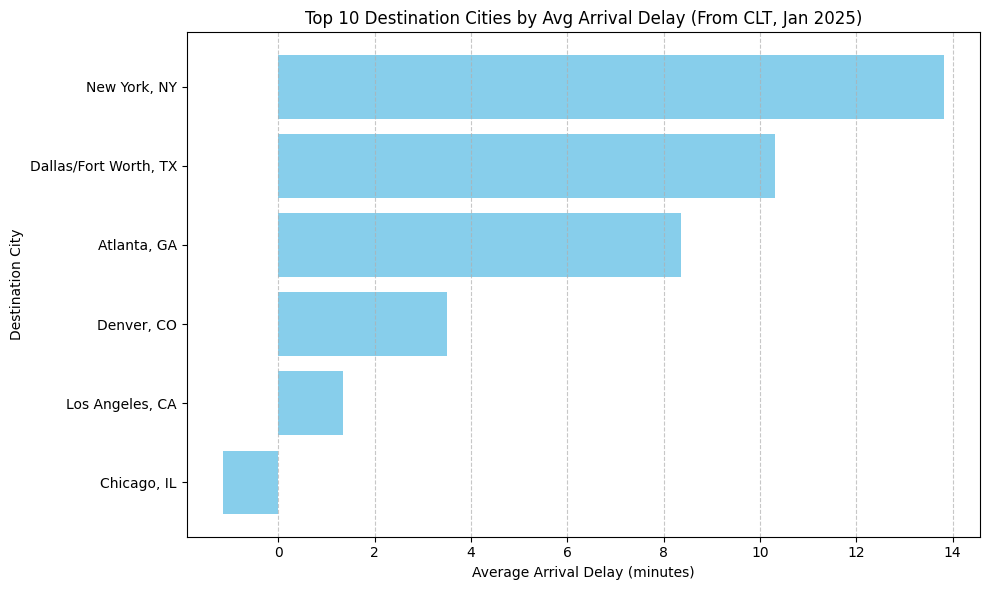

In [ ]:
import matplotlib.pyplot as plt

pandas_df = result_df.limit(10).toPandas()

pandas_df = pandas_df.sort_values(by="AvgArrDelay", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(pandas_df["DestCityName"], pandas_df["AvgArrDelay"], color='skyblue')
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Destination City")
plt.title("Top 10 Destination Cities by Avg Arrival Delay (From CLT, Jan 2025)")
plt.gca().invert_yaxis()  # Highest delay at top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
from pyspark.sql import Window
from pyspark.sql.functions import row_number

## Worst Delay Destinations per Airline

valid_flights = df.filter(col("Cancelled") == 0)

# Group by airline and destination city
airline_dest_delay = valid_flights.groupBy("Marketing_Airline_Network", "DestCityName").agg(
    count("*").alias("NumFlights"),
    avg("ArrDelay").alias("AvgArrDelay")
)

# Window spec: partition by airline, rank destinations by delay
windowSpec = Window.partitionBy("Marketing_Airline_Network").orderBy(desc("AvgArrDelay"))

ranked_delays = airline_dest_delay.withColumn("Rank", row_number().over(windowSpec))

top_delayed_destinations = ranked_delays.filter(col("Rank") <= 3)

# Replace airline codes with full names
airline_names = {
    'F9': 'Frontier Airlines',
    'NK': 'Spirit Airlines',
    'DL': 'Delta Air Lines',
    'AA': 'American Airlines',
    'UA': 'United Airlines',
    'WN': 'Southwest Airlines'
}

top_delayed_destinations_named = top_delayed_destinations.replace(
    to_replace=airline_names,
    subset=["Marketing_Airline_Network"]
).withColumnRenamed("Marketing_Airline_Network", "Airline")

top_delayed_destinations_named.orderBy("Airline", "Rank").show(truncate=False)

+------------------+---------------------+----------+-------------------+----+
|Airline           |DestCityName         |NumFlights|AvgArrDelay        |Rank|
+------------------+---------------------+----------+-------------------+----+
|American Airlines |New York, NY         |145       |13.372413793103448 |1   |
|American Airlines |Denver, CO           |137       |7.518248175182482  |2   |
|American Airlines |Dallas/Fort Worth, TX|318       |6.212698412698413  |3   |
|Delta Air Lines   |New York, NY         |116       |14.379310344827585 |1   |
|Delta Air Lines   |Atlanta, GA          |241       |12.630705394190871 |2   |
|Frontier Airlines |Dallas/Fort Worth, TX|15        |84.13333333333334  |1   |
|Frontier Airlines |Chicago, IL          |2         |-4.0               |2   |
|Frontier Airlines |Denver, CO           |18        |-9.166666666666666 |3   |
|Southwest Airlines|Denver, CO           |26        |-5.346153846153846 |1   |
|Spirit Airlines   |Dallas/Fort Worth, TX|7         

In [12]:
airline_summary = valid_flights.groupBy("Marketing_Airline_Network").agg(
    count("*").alias("TotalFlights"),
    avg("ArrDelay").alias("OverallAvgArrDelay")
)

airline_summary_named = airline_summary.replace(
    to_replace=airline_names,
    subset=["Marketing_Airline_Network"]
).withColumnRenamed("Marketing_Airline_Network", "Airline")

airline_summary_named.orderBy(desc("OverallAvgArrDelay")).show(truncate=False)

+------------------+------------+------------------+
|Airline           |TotalFlights|OverallAvgArrDelay|
+------------------+------------+------------------+
|Frontier Airlines |35          |31.114285714285714|
|Spirit Airlines   |15          |24.533333333333335|
|Delta Air Lines   |357         |13.198879551820728|
|American Airlines |1232        |4.316218418907906 |
|United Airlines   |152         |-1.256578947368421|
|Southwest Airlines|26          |-5.346153846153846|
+------------------+------------+------------------+



In [15]:
from pyspark.sql.functions import sum as _sum, col, round

valid_delay_flights = df.filter(
    (col("Cancelled") == 0) & (col("Diverted") == 0)
)

airline_delay_breakdown = valid_delay_flights.groupBy("Marketing_Airline_Network").agg(
    _sum("CarrierDelay").alias("CarrierDelayTotal"),
    _sum("WeatherDelay").alias("WeatherDelayTotal"),
    _sum("NASDelay").alias("NASDelayTotal"),
    _sum("SecurityDelay").alias("SecurityDelayTotal"),
    _sum("LateAircraftDelay").alias("LateAircraftDelayTotal"),
    _sum("ArrDelay").alias("TotalArrDelay")
)

airline_delay_breakdown = airline_delay_breakdown.withColumn(
    "CarrierDelayPct", round(col("CarrierDelayTotal") / col("TotalArrDelay") * 100, 1)
).withColumn(
    "WeatherDelayPct", round(col("WeatherDelayTotal") / col("TotalArrDelay") * 100, 1)
).withColumn(
    "NASDelayPct", round(col("NASDelayTotal") / col("TotalArrDelay") * 100, 1)
).withColumn(
    "SecurityDelayPct", round(col("SecurityDelayTotal") / col("TotalArrDelay") * 100, 1)
).withColumn(
    "LateAircraftDelayPct", round(col("LateAircraftDelayTotal") / col("TotalArrDelay") * 100, 1)
)

airline_delay_breakdown_named = airline_delay_breakdown.replace(
    to_replace=airline_names,
    subset=["Marketing_Airline_Network"]
).withColumnRenamed("Marketing_Airline_Network", "Airline")

airline_delay_breakdown_named.orderBy(col("TotalArrDelay").desc()).show(truncate=False)

+------------------+-----------------+-----------------+-------------+------------------+----------------------+-------------+---------------+---------------+-----------+----------------+--------------------+
|Airline           |CarrierDelayTotal|WeatherDelayTotal|NASDelayTotal|SecurityDelayTotal|LateAircraftDelayTotal|TotalArrDelay|CarrierDelayPct|WeatherDelayPct|NASDelayPct|SecurityDelayPct|LateAircraftDelayPct|
+------------------+-----------------+-----------------+-------------+------------------+----------------------+-------------+---------------+---------------+-----------+----------------+--------------------+
|American Airlines |4330.0           |368.0            |4381.0       |153.0             |4610.0                |5296.0       |81.8           |6.9            |82.7       |2.9             |87.0                |
|Delta Air Lines   |3596.0           |1106.0           |753.0        |0.0               |2713.0                |4712.0       |76.3           |23.5           |16.0  

In [16]:
valid_flights = df.filter(
    (col("Cancelled") == 0) & (col("Diverted") == 0)
)

carrier_delay_avg = valid_flights.groupBy("Marketing_Airline_Network").agg(
    _sum("CarrierDelay").alias("TotalCarrierDelay"),
    count("*").alias("TotalFlights")
)

carrier_delay_avg = carrier_delay_avg.withColumn(
    "AvgCarrierDelayPerFlight", round(col("TotalCarrierDelay") / col("TotalFlights"), 2)
)

carrier_delay_avg_named = carrier_delay_avg.replace(
    to_replace=airline_names,
    subset=["Marketing_Airline_Network"]
).withColumnRenamed("Marketing_Airline_Network", "Airline")

carrier_delay_avg_named.orderBy(col("AvgCarrierDelayPerFlight").desc()).show(truncate=False)

+------------------+-----------------+------------+------------------------+
|Airline           |TotalCarrierDelay|TotalFlights|AvgCarrierDelayPerFlight|
+------------------+-----------------+------------+------------------------+
|Frontier Airlines |1251.0           |35          |35.74                   |
|Delta Air Lines   |3596.0           |357         |10.07                   |
|Spirit Airlines   |113.0            |15          |7.53                    |
|American Airlines |4330.0           |1227        |3.53                    |
|Southwest Airlines|91.0             |26          |3.5                     |
|United Airlines   |182.0            |152         |1.2                     |
+------------------+-----------------+------------+------------------------+



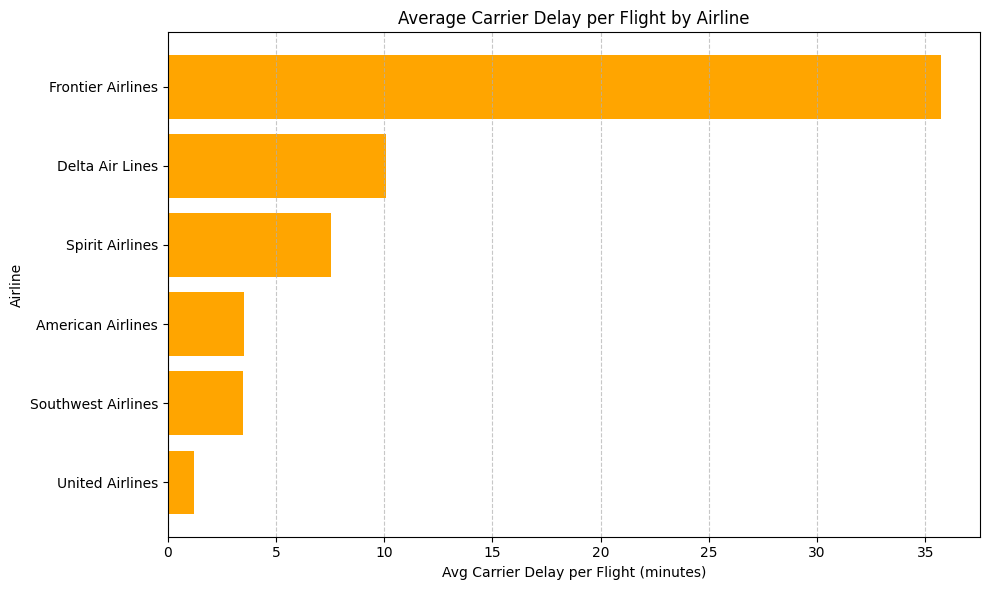

In [17]:
carrier_delay_pd = carrier_delay_avg_named.toPandas()

carrier_delay_pd = carrier_delay_pd.sort_values(by="AvgCarrierDelayPerFlight", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(carrier_delay_pd["Airline"], carrier_delay_pd["AvgCarrierDelayPerFlight"], color='orange')
plt.xlabel("Avg Carrier Delay per Flight (minutes)")
plt.ylabel("Airline")
plt.title("Average Carrier Delay per Flight by Airline")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()  # Highest delay on top
plt.tight_layout()
plt.show()

In [22]:
from pyspark.sql.functions import col, count, avg, round, sum, when

day_of_week_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

delay_by_day = valid_flights.groupBy("DayOfWeek").agg(
    count("*").alias("TotalFlights"),
    round(avg("ArrDelay"), 2).alias("AvgArrDelay"),
    round((sum(col("ArrDel15")) / count("*")) * 100, 2).alias("PctFlightsDelayed15Plus")
).withColumn(
    "DayOfWeekName",
    when(col("DayOfWeek") == 1, "Monday")
    .when(col("DayOfWeek") == 2, "Tuesday")
    .when(col("DayOfWeek") == 3, "Wednesday")
    .when(col("DayOfWeek") == 4, "Thursday")
    .when(col("DayOfWeek") == 5, "Friday")
    .when(col("DayOfWeek") == 6, "Saturday")
    .when(col("DayOfWeek") == 7, "Sunday")
    .otherwise("Unknown")
).orderBy(col("AvgArrDelay").desc())

delay_by_day.select("DayOfWeekName", "TotalFlights", "AvgArrDelay", "PctFlightsDelayed15Plus").show(truncate=False)

+-------------+------------+-----------+-----------------------+
|DayOfWeekName|TotalFlights|AvgArrDelay|PctFlightsDelayed15Plus|
+-------------+------------+-----------+-----------------------+
|Monday       |248         |20.8       |32.66                  |
|Sunday       |252         |11.41      |23.02                  |
|Tuesday      |229         |5.39       |19.65                  |
|Friday       |280         |4.95       |18.57                  |
|Saturday     |218         |3.73       |20.64                  |
|Thursday     |305         |0.72       |15.74                  |
|Wednesday    |280         |-1.98      |13.21                  |
+-------------+------------+-----------+-----------------------+



In [ ]:
from pyspark.sql.functions import collect_set, weekofyear

weather_delays = df.filter(col("WeatherDelay") > 0)

df_with_week = df.withColumn("WeekOfYear", weekofyear(col("FlightDate")))

weather_delays = df_with_week.filter(col("WeatherDelay") > 0)

weather_delay_by_month_dest = weather_delays.groupBy("Month", "DestCityName").agg(
    count("*").alias("NumWeatherDelays"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelayMinutes"),
    collect_set("WeekOfYear").alias("WeeksWithDelays")
).orderBy(col("AvgWeatherDelayMinutes").desc())

weather_delay_by_month_dest.show(truncate=False)

+-----+---------------------+----------------+----------------------+---------------+
|Month|DestCityName         |NumWeatherDelays|AvgWeatherDelayMinutes|WeeksWithDelays|
+-----+---------------------+----------------+----------------------+---------------+
|1    |Atlanta, GA          |3               |339.0                 |[2]            |
|1    |New York, NY         |3               |104.33                |[2, 3, 5]      |
|1    |Dallas/Fort Worth, TX|2               |53.5                  |[2, 4]         |
|1    |Chicago, IL          |1               |32.0                  |[4]            |
|1    |Los Angeles, CA      |1               |5.0                   |[4]            |
+-----+---------------------+----------------+----------------------+---------------+



In [ ]:

all_time_blocks = df.select("DepTimeBlk").distinct()

weather_delays = df.filter(col("WeatherDelay") > 0)

weather_delay_by_time = weather_delays.groupBy("DepTimeBlk").agg(
    count("*").alias("NumWeatherDelays"),
    round(avg("WeatherDelay"), 2).alias("AvgWeatherDelayMinutes")
)

full_weather_delay_by_time = all_time_blocks.join(
    weather_delay_by_time,
    on="DepTimeBlk",
    how="left"
).orderBy("DepTimeBlk")

full_weather_delay_by_time = full_weather_delay_by_time.fillna({
    "NumWeatherDelays": 0,
    "AvgWeatherDelayMinutes": 0
})

full_weather_delay_by_time.show(truncate=False)

+----------+----------------+----------------------+
|DepTimeBlk|NumWeatherDelays|AvgWeatherDelayMinutes|
+----------+----------------+----------------------+
|0001-0559 |1               |70.0                  |
|0600-0659 |0               |0.0                   |
|0700-0759 |1               |436.0                 |
|0800-0859 |0               |0.0                   |
|0900-0959 |0               |0.0                   |
|1000-1059 |1               |249.0                 |
|1100-1159 |0               |0.0                   |
|1200-1259 |0               |0.0                   |
|1300-1359 |1               |104.0                 |
|1400-1459 |0               |0.0                   |
|1500-1559 |0               |0.0                   |
|1600-1659 |1               |120.0                 |
|1700-1759 |1               |89.0                  |
|1800-1859 |1               |332.0                 |
|1900-1959 |0               |0.0                   |
|2000-2059 |2               |18.5             

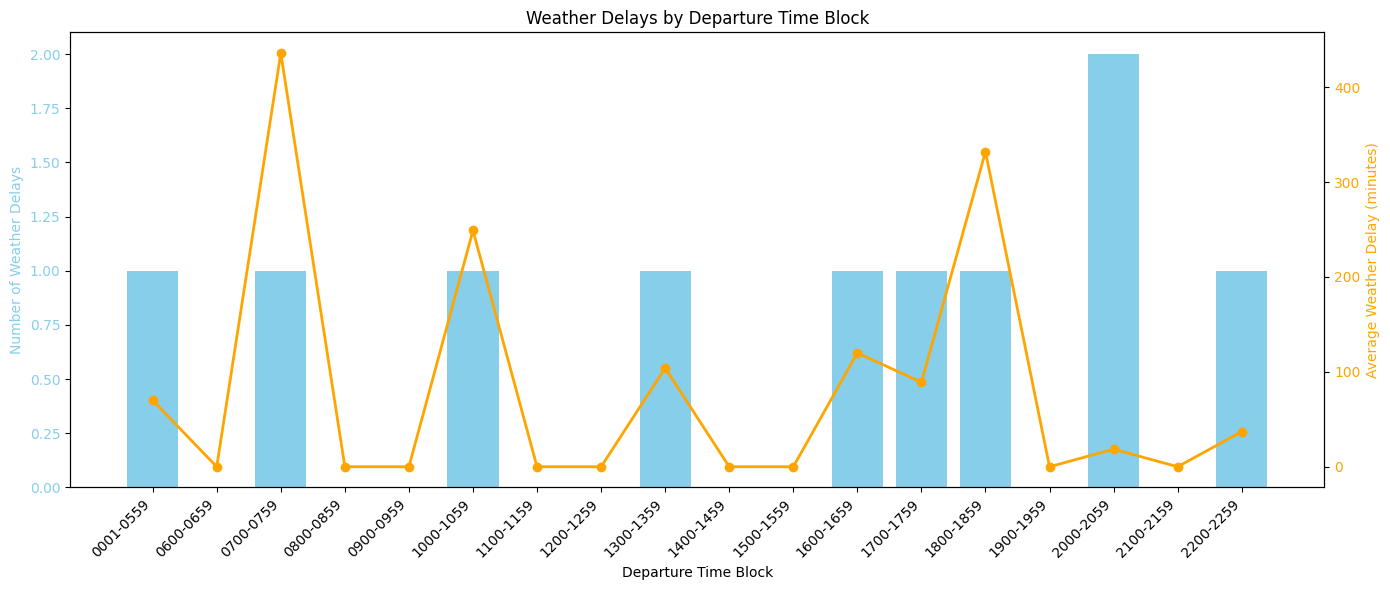

In [ ]:

pdf = full_weather_delay_by_time.toPandas()

pdf = pdf.sort_values("DepTimeBlk")

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(pdf["DepTimeBlk"], pdf["NumWeatherDelays"], color='skyblue')
ax1.set_xlabel('Departure Time Block')
ax1.set_ylabel('Number of Weather Delays', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(pdf["DepTimeBlk"], pdf["AvgWeatherDelayMinutes"], color='orange', marker='o', linewidth=2)
ax2.set_ylabel('Average Weather Delay (minutes)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Weather Delays by Departure Time Block')
plt.tight_layout()
plt.show()